<a href="https://colab.research.google.com/github/nimmakayalaakshaya/akshaya_nimmakayala/blob/main/phase1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
#1:Loading the dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
%matplotlib inline

url = "https://raw.githubusercontent.com/salemprakash/EDA/main/Data/constituents.csv"

df = pd.read_csv(url)

print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
display(df.head())

Dataset Shape: (503, 8)

First 5 Rows:


,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989


In [5]:
# 2: Basic Statistical Analysis

print("Dataset Info:")
df.info()

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 503 entries, 0 to 502
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Symbol                 503 non-null    object
 1   Security               503 non-null    object
 2   GICS Sector            503 non-null    object
 3   GICS Sub-Industry      503 non-null    object
 4   Headquarters Location  503 non-null    object
 5   Date added             503 non-null    object
 6   CIK                    503 non-null    int64 
 7   Founded                503 non-null    object
dtypes: int64(1), object(7)
memory usage: 31.6+ KB
Rows: 503
Columns: 8


In [6]:
print("\nSummary Statistics (Numerical Columns):")
df.describe()


Summary Statistics (Numerical Columns):


,CIK
count,5.030000e+02
mean,8.217536e+05
std,5.665200e+05
min,1.800000e+03
25%,1.005050e+05
50%,9.000750e+05
75%,1.175188e+06
max,2.005951e+06


In [7]:
print("Summary Statistics (Categorical Columns):")
df.describe(include='object')


Summary Statistics (Categorical Columns):


,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,Founded
count,503,503,503,503,503,503,503
unique,503,503,11,127,252,376,199
top,ZTS,Zoetis,Industrials,Health Care Equipment,"New York City, New York",1957-03-04,1993
freq,1,1,78,18,41,54,13


In [8]:
print("Column Names:", list(df.columns))
print("\nData Types:\n", df.dtypes)

Column Names: ['Symbol', 'Security', 'GICS Sector', 'GICS Sub-Industry', 'Headquarters Location', 'Date added', 'CIK', 'Founded']

Data Types:
 Symbol                   object
Security                 object
GICS Sector              object
GICS Sub-Industry        object
Headquarters Location    object
Date added               object
CIK                       int64
Founded                  object
dtype: object


In [9]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
print("Numeric Columns:", numeric_cols)

for col in numeric_cols:
    print(f"\n--- {col} ---")
    print(f"Mean   : {df[col].mean():.2f}")
    print(f"Median : {df[col].median():.2f}")
    print(f"Mode   : {df[col].mode()[0]}")
    print(f"Std Dev: {df[col].std():.2f}")
    print(f"Variance: {df[col].var():.2f}")
    print(f"Min    : {df[col].min()}")
    print(f"Max    : {df[col].max()}")

Numeric Columns: ['CIK']

--- CIK ---
Mean   : 821753.65
Median : 900075.00
Mode   : 1564708
Std Dev: 566520.03
Variance: 320944944548.38
Min    : 1800
Max    : 2005951


In [10]:
#  3: Handling Missing Data
print("Missing Values per Column:")
print(df.isnull().sum())

print("\nPercentage of Missing Values per Column:")
print((df.isnull().sum() / len(df)) * 100)

Missing Values per Column:
Symbol                   0
Security                 0
GICS Sector              0
GICS Sub-Industry        0
Headquarters Location    0
Date added               0
CIK                      0
Founded                  0
dtype: int64

Percentage of Missing Values per Column:
Symbol                   0.0
Security                 0.0
GICS Sector              0.0
GICS Sub-Industry        0.0
Headquarters Location    0.0
Date added               0.0
CIK                      0.0
Founded                  0.0
dtype: float64


In [11]:
print("Rows before handling missing data:", df.shape[0])


numeric_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(include='object').columns

for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"Filled missing values in '{col}' with median: {median_val}")

for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)
        print(f"Filled missing values in '{col}' with mode: {mode_val}")

print("\nMissing values after handling:")
print(df.isnull().sum())

Rows before handling missing data: 503

Missing values after handling:
Symbol                   0
Security                 0
GICS Sector              0
GICS Sub-Industry        0
Headquarters Location    0
Date added               0
CIK                      0
Founded                  0
dtype: int64


In [12]:
#4: Data Cleaning

if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)
    print("Dropped 'Unnamed: 0' column.")

elif 'rownames' in df.columns:
    df.drop(columns=['rownames'], inplace=True)
    print("Dropped 'rownames' column.")

print("Columns after dropping index column:", list(df.columns))

Columns after dropping index column: ['Symbol', 'Security', 'GICS Sector', 'GICS Sub-Industry', 'Headquarters Location', 'Date added', 'CIK', 'Founded']


In [13]:
print("Number of duplicate rows:", df.duplicated().sum())

df.drop_duplicates(inplace=True)
print("Shape after removing duplicates:", df.shape)

Number of duplicate rows: 0
Shape after removing duplicates: (503, 8)


In [14]:
categorical_cols = df.select_dtypes(include='object').columns
print("Categorical columns:", list(categorical_cols))

for col in categorical_cols:
    df[col] = df[col].astype(str).str.strip().str.lower()

print("\nUnique values in each categorical column after cleaning:")
for col in categorical_cols:
    print(f"{col}: {df[col].unique()}")

Categorical columns: ['Symbol', 'Security', 'GICS Sector', 'GICS Sub-Industry', 'Headquarters Location', 'Date added', 'Founded']

Unique values in each categorical column after cleaning:
Symbol: ['mmm' 'aos' 'abt' 'abbv' 'acn' 'adbe' 'amd' 'aes' 'afl' 'a' 'apd' 'abnb'
 'akam' 'alb' 'are' 'algn' 'alle' 'lnt' 'all' 'googl' 'goog' 'mo' 'amzn'
 'amcr' 'aee' 'aal' 'aep' 'axp' 'aig' 'amt' 'awk' 'amp' 'ame' 'amgn' 'aph'
 'adi' 'anss' 'aon' 'apa' 'aapl' 'amat' 'aptv' 'acgl' 'adm' 'anet' 'ajg'
 'aiz' 't' 'ato' 'adsk' 'adp' 'azo' 'avb' 'avy' 'axon' 'bkr' 'ball' 'bac'
 'bk' 'bbwi' 'bax' 'bdx' 'brk.b' 'bby' 'bio' 'tech' 'biib' 'blk' 'bx' 'ba'
 'bkng' 'bwa' 'bsx' 'bmy' 'avgo' 'br' 'bro' 'bf.b' 'bldr' 'bg' 'bxp'
 'chrw' 'cdns' 'czr' 'cpt' 'cpb' 'cof' 'cah' 'kmx' 'ccl' 'carr' 'ctlt'
 'cat' 'cboe' 'cbre' 'cdw' 'ce' 'cor' 'cnc' 'cnp' 'cf' 'crl' 'schw' 'chtr'
 'cvx' 'cmg' 'cb' 'chd' 'ci' 'cinf' 'ctas' 'csco' 'c' 'cfg' 'clx' 'cme'
 'cms' 'ko' 'ctsh' 'cl' 'cmcsa' 'cag' 'cop' 'ed' 'stz' 'ceg' 'coo' 'cprt'

In [15]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"{col}: {len(outliers)} outliers detected (range: {lower_bound:.2f} to {upper_bound:.2f})")


CIK: 0 outliers detected (range: -1511519.50 to 2787212.50)


In [16]:

print("Final Dataset Shape:", df.shape)
df.head()

Final Dataset Shape: (503, 8)


,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,mmm,3m,industrials,industrial conglomerates,"saint paul, minnesota",1957-03-04,66740,1902
1,aos,a. o. smith,industrials,building products,"milwaukee, wisconsin",2017-07-26,91142,1916
2,abt,abbott laboratories,health care,health care equipment,"north chicago, illinois",1957-03-04,1800,1888
3,abbv,abbvie,health care,biotechnology,"north chicago, illinois",2012-12-31,1551152,2013 (1888)
4,acn,accenture,information technology,it consulting & other services,"dublin, ireland",2011-07-06,1467373,1989


In [17]:
# 5: Data Transformation

from sklearn.preprocessing import LabelEncoder

df_transformed = df.copy()

le = LabelEncoder()
categorical_cols = df_transformed.select_dtypes(include='object').columns

for col in categorical_cols:
    df_transformed[col + '_encoded'] = le.fit_transform(df_transformed[col])
    print(f"Encoded '{col}': {dict(zip(le.classes_, le.transform(le.classes_)))}")

df_transformed.head()

Encoded 'Symbol': {'a': np.int64(0), 'aal': np.int64(1), 'aapl': np.int64(2), 'abbv': np.int64(3), 'abnb': np.int64(4), 'abt': np.int64(5), 'acgl': np.int64(6), 'acn': np.int64(7), 'adbe': np.int64(8), 'adi': np.int64(9), 'adm': np.int64(10), 'adp': np.int64(11), 'adsk': np.int64(12), 'aee': np.int64(13), 'aep': np.int64(14), 'aes': np.int64(15), 'afl': np.int64(16), 'aig': np.int64(17), 'aiz': np.int64(18), 'ajg': np.int64(19), 'akam': np.int64(20), 'alb': np.int64(21), 'algn': np.int64(22), 'all': np.int64(23), 'alle': np.int64(24), 'amat': np.int64(25), 'amcr': np.int64(26), 'amd': np.int64(27), 'ame': np.int64(28), 'amgn': np.int64(29), 'amp': np.int64(30), 'amt': np.int64(31), 'amzn': np.int64(32), 'anet': np.int64(33), 'anss': np.int64(34), 'aon': np.int64(35), 'aos': np.int64(36), 'apa': np.int64(37), 'apd': np.int64(38), 'aph': np.int64(39), 'aptv': np.int64(40), 'are': np.int64(41), 'ato': np.int64(42), 'avb': np.int64(43), 'avgo': np.int64(44), 'avy': np.int64(45), 'awk': np.

,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded,Symbol_encoded,Security_encoded,GICS Sector_encoded,GICS Sub-Industry_encoded,Headquarters Location_encoded,Date added_encoded,Founded_encoded
0,mmm,3m,industrials,industrial conglomerates,"saint paul, minnesota",1957-03-04,66740,1902,314,0,6,66,196,0,52
1,aos,a. o. smith,industrials,building products,"milwaukee, wisconsin",2017-07-26,91142,1916,36,1,6,16,144,289,64
2,abt,abbott laboratories,health care,health care equipment,"north chicago, illinois",1957-03-04,1800,1888,5,2,5,51,160,0,41
3,abbv,abbvie,health care,biotechnology,"north chicago, illinois",2012-12-31,1551152,2013 (1888),3,3,5,12,160,227,176
4,acn,accenture,information technology,it consulting & other services,"dublin, ireland",2011-07-06,1467373,1989,7,4,7,77,63,209,139


In [18]:
from sklearn.preprocessing import MinMaxScaler

df_transformed = df.copy()

scaler = MinMaxScaler()

df_transformed['CIK_scaled'] = scaler.fit_transform(df_transformed[['CIK']])

display(df_transformed.head())

,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded,CIK_scaled
0,mmm,3m,industrials,industrial conglomerates,"saint paul, minnesota",1957-03-04,66740,1902,0.032403
1,aos,a. o. smith,industrials,building products,"milwaukee, wisconsin",2017-07-26,91142,1916,0.044578
2,abt,abbott laboratories,health care,health care equipment,"north chicago, illinois",1957-03-04,1800,1888,0.000000
3,abbv,abbvie,health care,biotechnology,"north chicago, illinois",2012-12-31,1551152,2013 (1888),0.773071
4,acn,accenture,information technology,it consulting & other services,"dublin, ireland",2011-07-06,1467373,1989,0.731269


In [19]:
print("Transformed Dataset Shape:", df_transformed.shape)
print("\nColumns after transformation:", list(df_transformed.columns))
df_transformed.describe()

Transformed Dataset Shape: (503, 9)

Columns after transformation: ['Symbol', 'Security', 'GICS Sector', 'GICS Sub-Industry', 'Headquarters Location', 'Date added', 'CIK', 'Founded', 'CIK_scaled']


,CIK,CIK_scaled
count,5.030000e+02,503.000000
mean,8.217536e+05,0.409128
std,5.665200e+05,0.282673
min,1.800000e+03,0.000000
25%,1.005050e+05,0.049250
50%,9.000750e+05,0.448207
75%,1.175188e+06,0.585479
max,2.005951e+06,1.000000


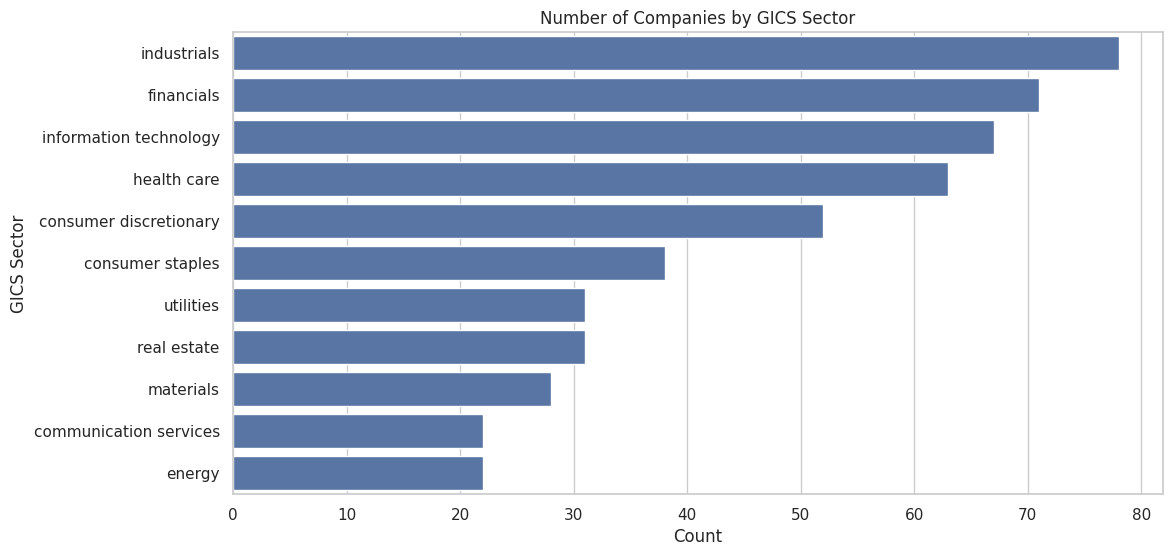

In [20]:
#6: Univariate Analysis
plt.figure(figsize=(12,6))

sns.countplot(
    y='GICS Sector',
    data=df,
    order=df['GICS Sector'].value_counts().index
)

plt.title("Number of Companies by GICS Sector")
plt.xlabel("Count")
plt.ylabel("GICS Sector")
plt.show()

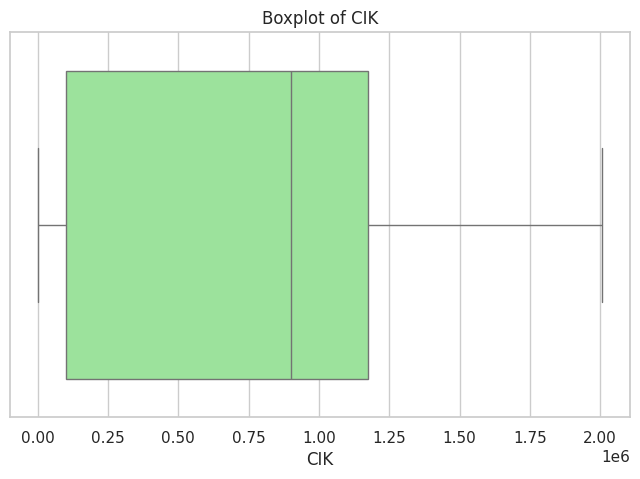

In [21]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['CIK'], color='lightgreen')

plt.title("Boxplot of CIK")
plt.xlabel("CIK")

plt.show()

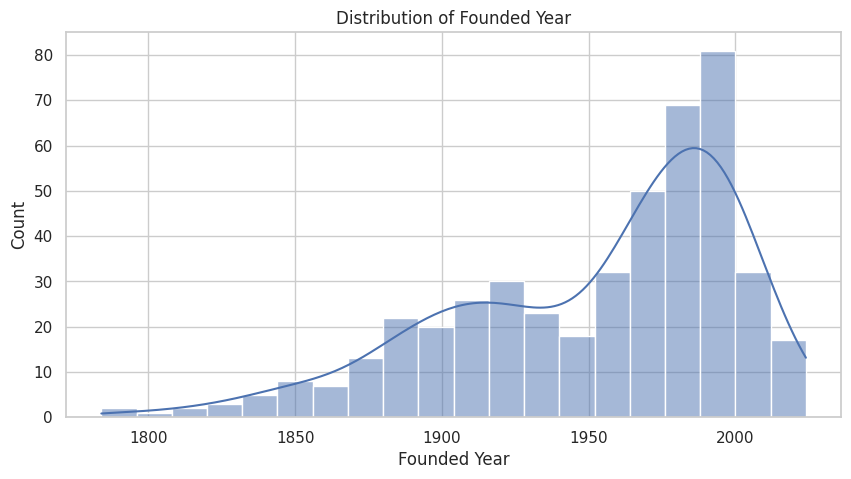

In [22]:
plt.figure(figsize=(10,5))

founded = pd.to_numeric(df['Founded'], errors='coerce')

sns.histplot(founded.dropna(), bins=20, kde=True)

plt.title("Distribution of Founded Year")
plt.xlabel("Founded Year")

plt.show()

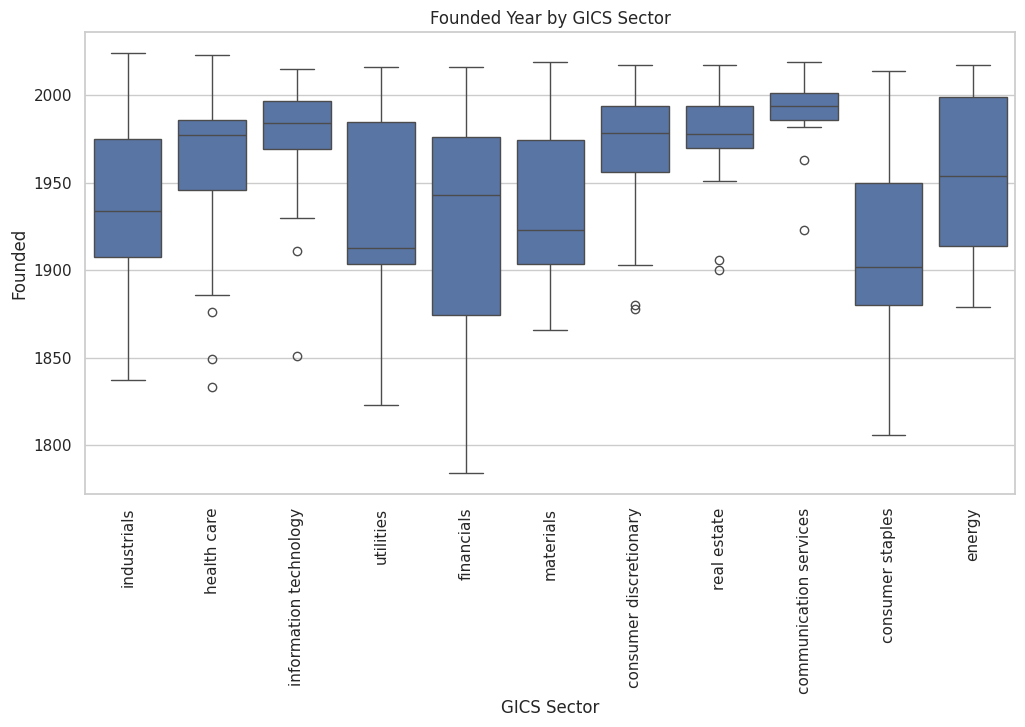

In [23]:
#7: Bivariate Analysis
plt.figure(figsize=(12,6))

df['Founded'] = pd.to_numeric(df['Founded'], errors='coerce')

sns.boxplot(
    x='GICS Sector',
    y='Founded',
    data=df
)

plt.xticks(rotation=90)

plt.title("Founded Year by GICS Sector")

plt.show()

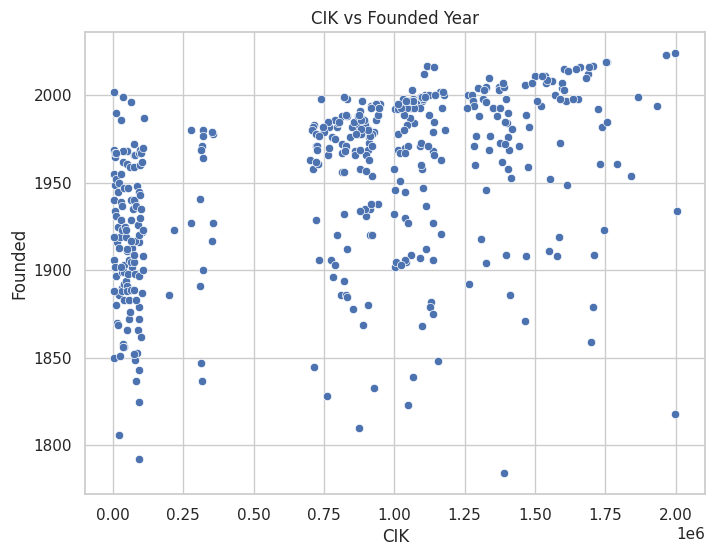

In [24]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='CIK',
    y='Founded',
    data=df
)

plt.title("CIK vs Founded Year")

plt.show()

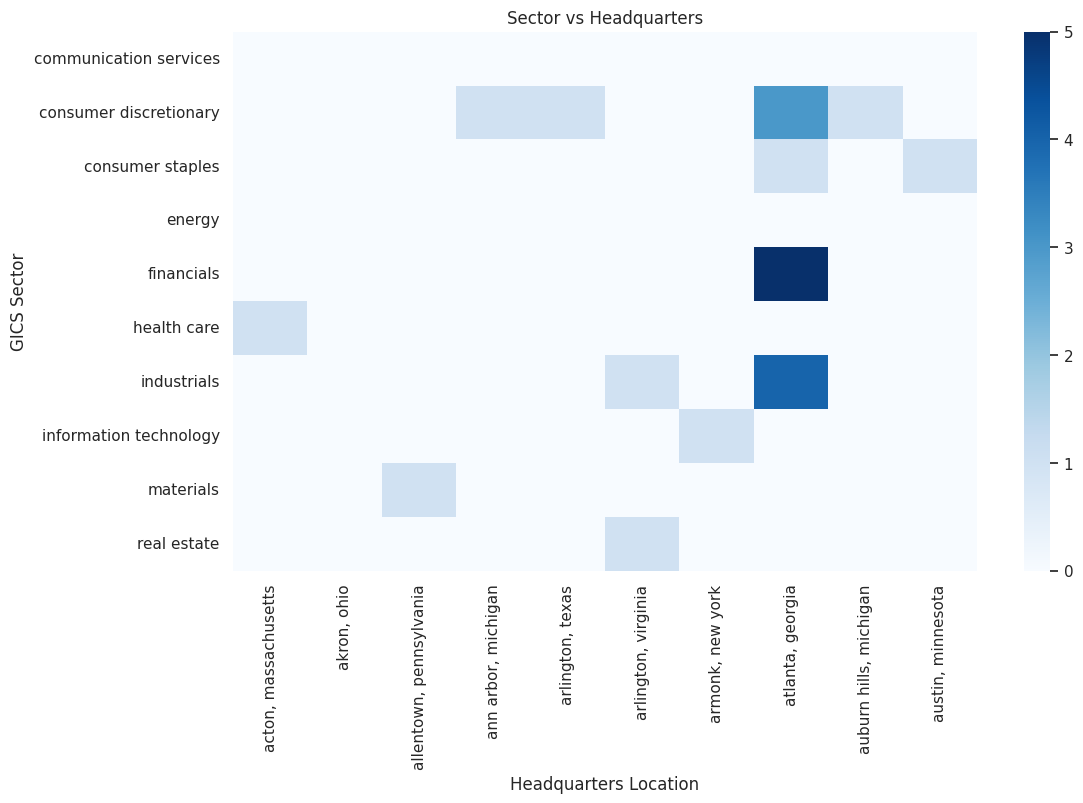

In [25]:
cross = pd.crosstab(
    df['GICS Sector'],
    df['Headquarters Location']
)

plt.figure(figsize=(12,7))

sns.heatmap(
    cross.iloc[:10,:10],
    cmap='Blues'
)

plt.title("Sector vs Headquarters")

plt.show()

In [26]:
#8: Multivariate Analysis

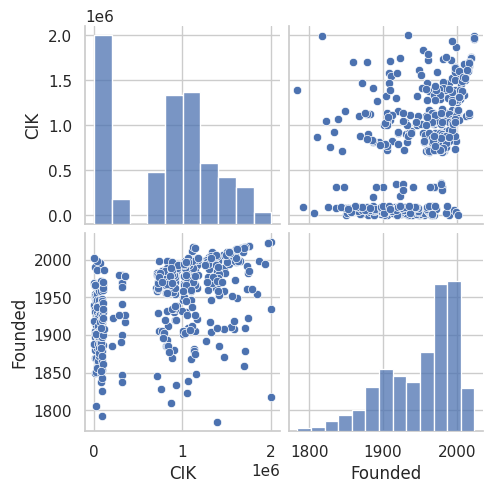

In [27]:
df_pair = df.copy()

df_pair['Founded'] = pd.to_numeric(df_pair['Founded'], errors='coerce')

sns.pairplot(
    df_pair[['CIK','Founded']].dropna()
)

plt.show()

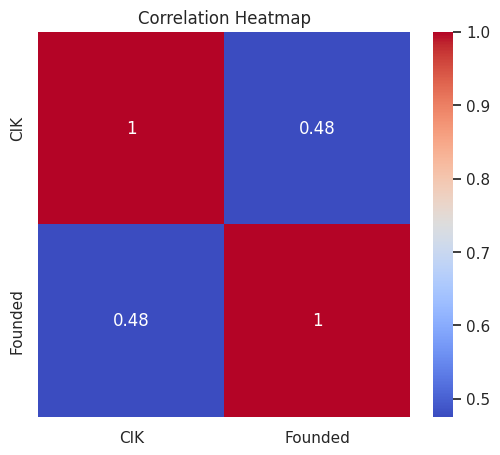

In [28]:
plt.figure(figsize=(6,5))

corr = df[['CIK']].copy()

corr['Founded'] = pd.to_numeric(df['Founded'], errors='coerce')

sns.heatmap(
    corr.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

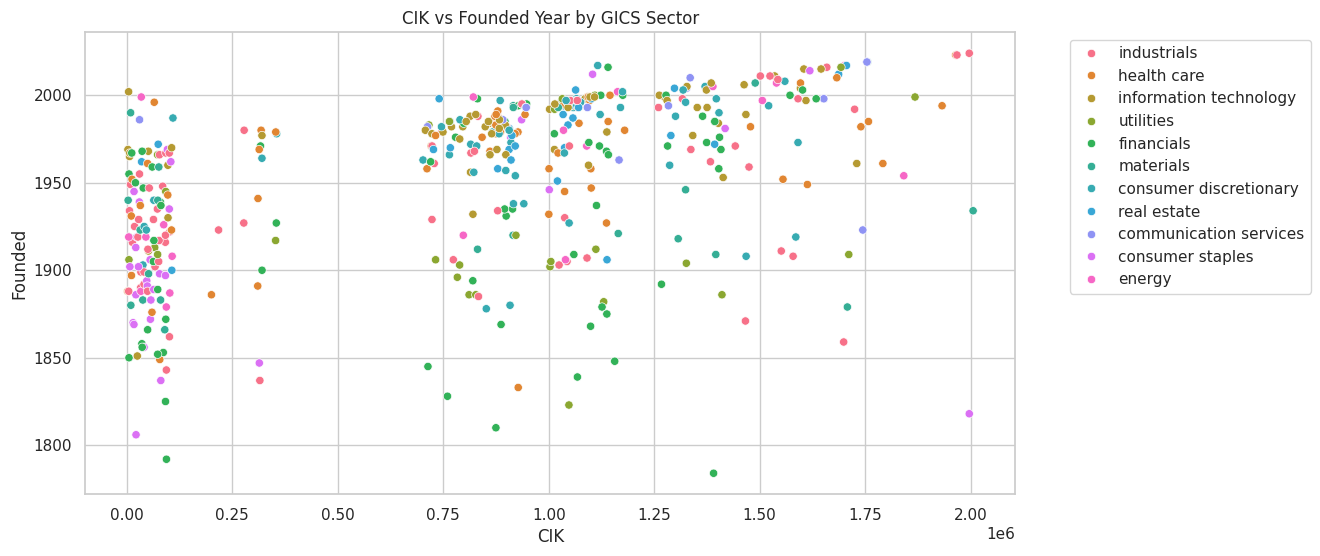

In [29]:
plt.figure(figsize=(12,6))

sns.scatterplot(
    data=df,
    x='CIK',
    y=pd.to_numeric(df['Founded'], errors='coerce'),
    hue='GICS Sector'
)

plt.title("CIK vs Founded Year by GICS Sector")

plt.legend(
    bbox_to_anchor=(1.05,1),
    loc='upper left'
)

plt.show()

In [31]:
print("\n===== 1D ANALYSIS =====")

print("\nFounded Statistics:")
print(df["Founded"].describe())

print("\nCIK Statistics:")
print(df["CIK"].describe())

print("\nSector Frequency:")
print(df["GICS Sector"].value_counts())


===== 1D ANALYSIS =====

Founded Statistics:
count     461.000000
mean     1952.097614
std        48.390005
min      1784.000000
25%      1919.000000
50%      1968.000000
75%      1992.000000
max      2024.000000
Name: Founded, dtype: float64

CIK Statistics:
count    5.030000e+02
mean     8.217536e+05
std      5.665200e+05
min      1.800000e+03
25%      1.005050e+05
50%      9.000750e+05
75%      1.175188e+06
max      2.005951e+06
Name: CIK, dtype: float64

Sector Frequency:
GICS Sector
industrials               78
financials                71
information technology    67
health care               63
consumer discretionary    52
consumer staples          38
utilities                 31
real estate               31
materials                 28
communication services    22
energy                    22
Name: count, dtype: int64


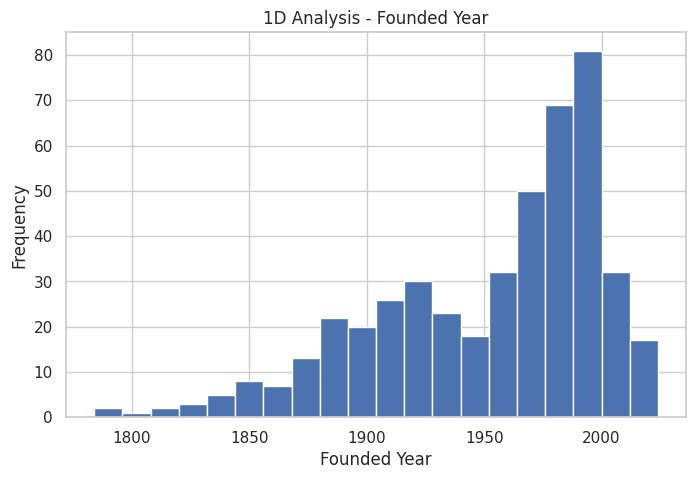

In [32]:
# Histogram
plt.figure(figsize=(8,5))
plt.hist(df["Founded"].dropna(), bins=20)
plt.xlabel("Founded Year")
plt.ylabel("Frequency")
plt.title("1D Analysis - Founded Year")
plt.show()

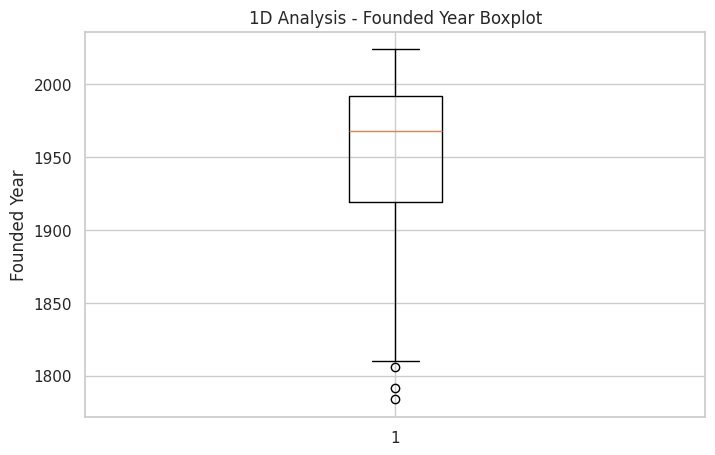

In [33]:
# Boxplot
plt.figure(figsize=(8,5))
plt.boxplot(df["Founded"].dropna().astype(float))
plt.ylabel("Founded Year")
plt.title("1D Analysis - Founded Year Boxplot")
plt.show()

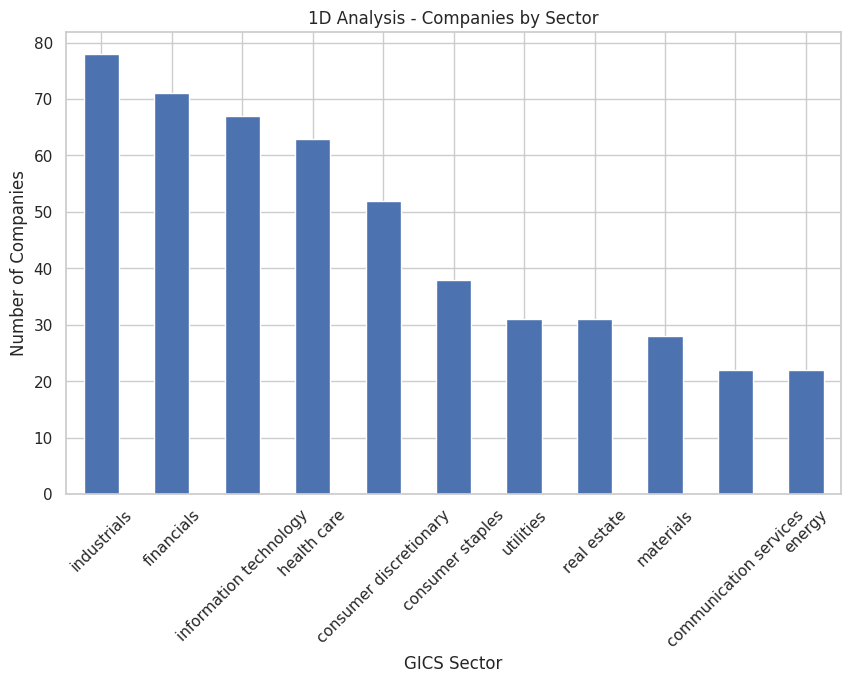

In [34]:
# Sector bar chart
plt.figure(figsize=(10,6))
df["GICS Sector"].value_counts().plot(kind="bar")
plt.xlabel("GICS Sector")
plt.ylabel("Number of Companies")
plt.title("1D Analysis - Companies by Sector")
plt.xticks(rotation=45)
plt.show()




===== 2D ANALYSIS =====

Correlation:
          Founded       CIK
Founded  1.000000  0.475457
CIK      0.475457  1.000000


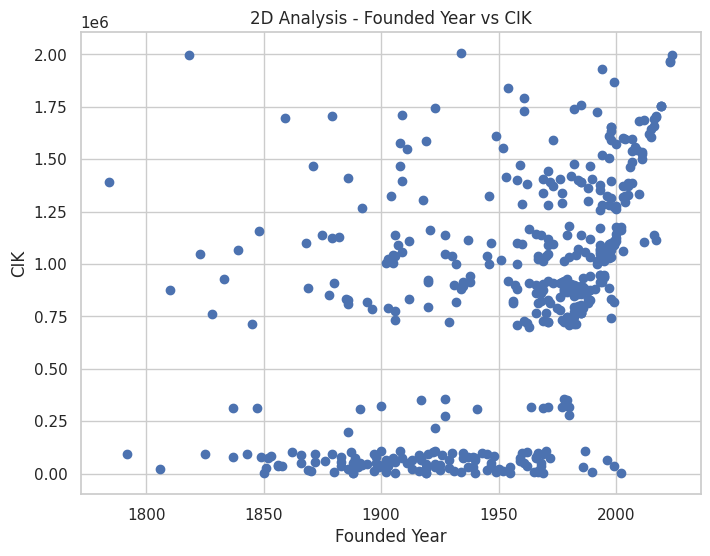

In [38]:
print("\n===== 2D ANALYSIS =====")

data2d = df[["Founded", "CIK"]].dropna()

print("\nCorrelation:")
print(data2d.corr())

plt.figure(figsize=(8,6))

plt.scatter(
    data2d["Founded"],
        data2d["CIK"]
        )

plt.xlabel("Founded Year")
plt.ylabel("CIK")
plt.title("2D Analysis - Founded Year vs CIK")
plt.show()

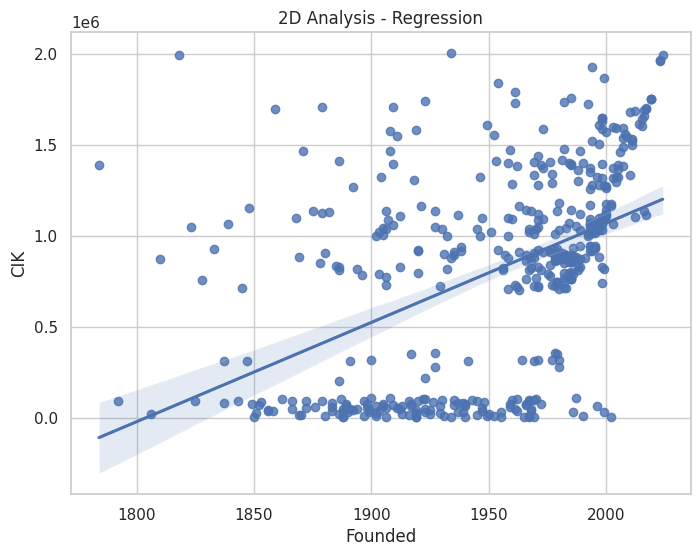

In [41]:
# Regression plot
plt.figure(figsize=(8,6))
sns.regplot(
    x="Founded",
        y="CIK",
            data=data2d
            )
plt.title("2D Analysis - Regression")
plt.show()


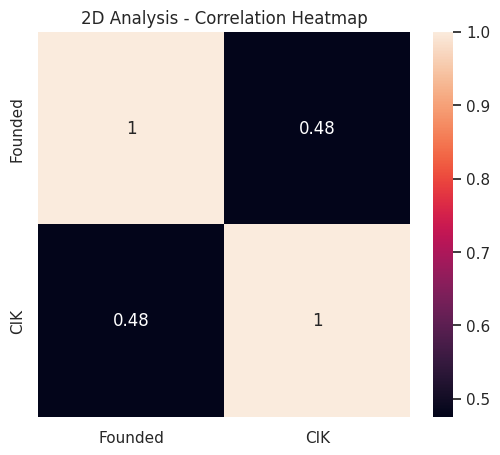

In [40]:
# Correlation heatmap
plt.figure(figsize=(6,5))
sns.heatmap(
    data2d.corr(),
        annot=True
        )
plt.title("2D Analysis - Correlation Heatmap")
plt.show()


In [45]:
df["Founded"] = pd.to_numeric(df["Founded"], errors="coerce")
df["CIK"] = pd.to_numeric(df["CIK"], errors="coerce")

df["Added_Year"] = pd.to_datetime(
    df["Date added"],
        errors="coerce"
        ).dt.year

print(df[["Founded", "CIK", "Added_Year"]].head())

   Founded      CIK  Added_Year
0   1902.0    66740        1957
1   1916.0    91142        2017
2   1888.0     1800        1957
3      NaN  1551152        2012
4   1989.0  1467373        2011



===== 3D ANALYSIS =====


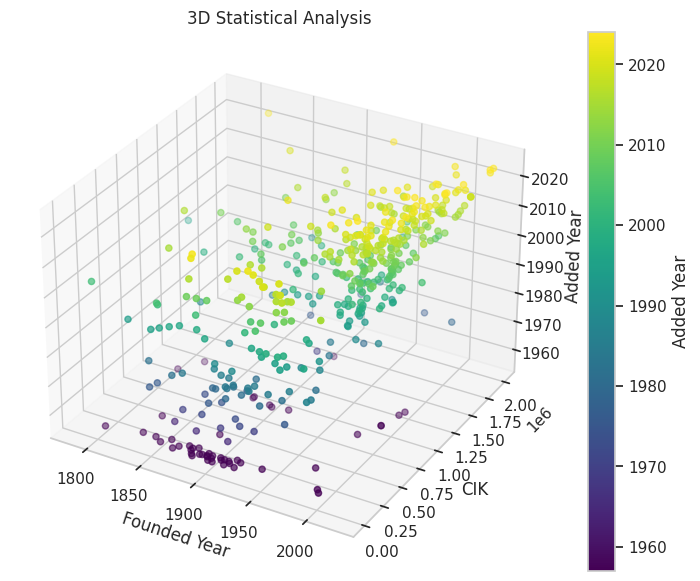

In [46]:
print("\n===== 3D ANALYSIS =====")

data3d = df[["Founded", "CIK", "Added_Year"]].dropna()

fig = plt.figure(figsize=(10,7))

ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    data3d["Founded"],
        data3d["CIK"],
            data3d["Added_Year"],
                c=data3d["Added_Year"],
                    cmap="viridis"
                    )

ax.set_xlabel("Founded Year")
ax.set_ylabel("CIK")
ax.set_zlabel("Added Year")
ax.set_title("3D Statistical Analysis")
plt.colorbar(
                        scatter,
                            label="Added Year"
                            )

plt.show()

In [48]:
#KMEANS CLUSTERING
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

features = data3d[["Founded", "CIK", "Added_Year"]]

scaler = StandardScaler()
X = scaler.fit_transform(features)

print(X[:5])

[[-1.03641316 -1.33731803 -2.1909728 ]
 [-0.74678291 -1.29339554  0.79142423]
 [-1.3260434  -1.45420708 -2.1909728 ]
 [ 0.76343194  1.18375775  0.49318453]
 [ 0.61861682 -0.02406577 -0.20270811]]


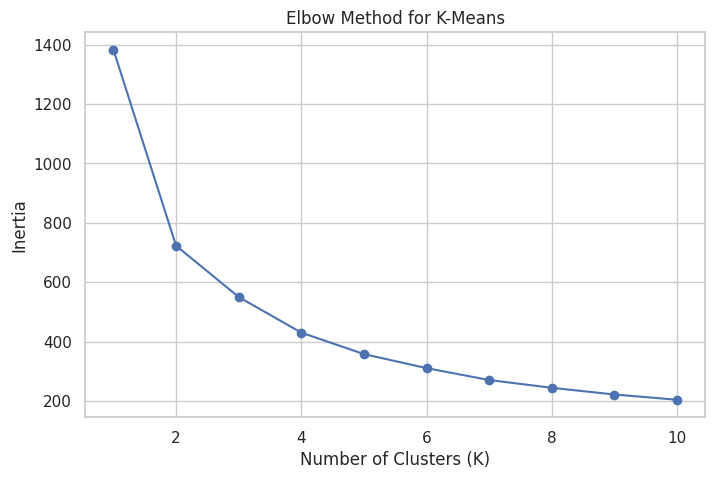

In [49]:
inertia = []

for k in range(1, 11):
    kmeans = KMeans(
            n_clusters=k,
                    random_state=42,
                            n_init=10
                                )
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1, 11), inertia, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")
plt.show()

In [50]:
kmeans = KMeans(
      n_clusters=3,
          random_state=42,
              n_init=10
              )

data3d["KMeans_Cluster"] = kmeans.fit_predict(X)

print(data3d.head())

print("\nCluster Counts:")
print(data3d["KMeans_Cluster"].value_counts())


   Founded      CIK  Added_Year  KMeans_Cluster
0   1902.0    66740        1957               1
1   1916.0    91142        2017               0
2   1888.0     1800        1957               1
4   1989.0  1467373        2011               2
5   1982.0   796343        1997               2

Cluster Counts:
KMeans_Cluster
2    252
0    114
1     95
Name: count, dtype: int64


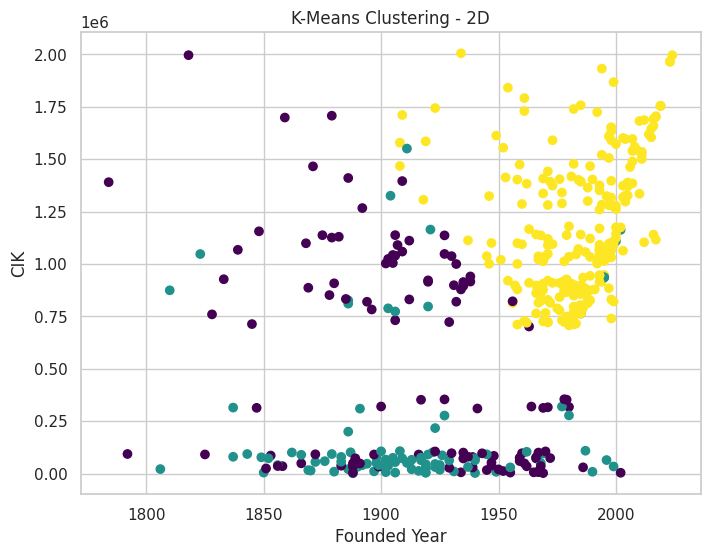

In [51]:
plt.figure(figsize=(8,6))

plt.scatter(
    data3d["Founded"],
        data3d["CIK"],
            c=data3d["KMeans_Cluster"],
                cmap="viridis"
                )

plt.xlabel("Founded Year")
plt.ylabel("CIK")
plt.title("K-Means Clustering - 2D")

plt.show()

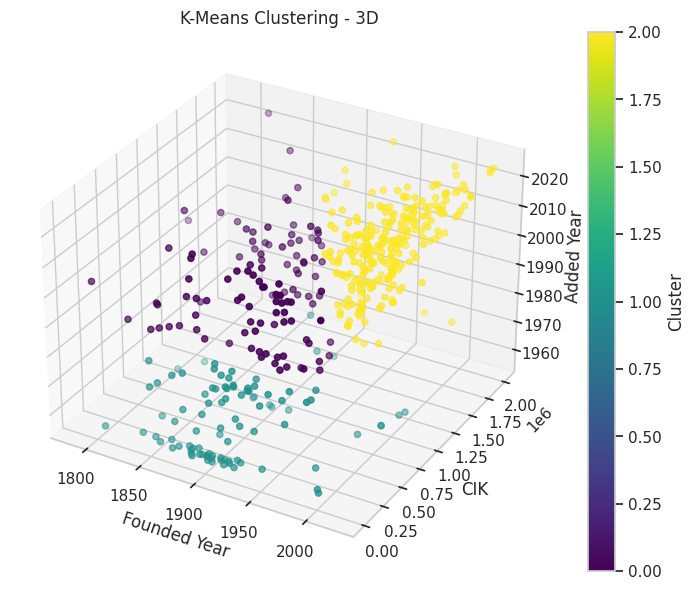

In [52]:
fig = plt.figure(figsize=(10,7))

ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    data3d["Founded"],
        data3d["CIK"],
            data3d["Added_Year"],
                c=data3d["KMeans_Cluster"],
                    cmap="viridis"
                    )

ax.set_xlabel("Founded Year")
ax.set_ylabel("CIK")
ax.set_zlabel("Added Year")

ax.set_title("K-Means Clustering - 3D")

plt.colorbar(
              scatter,
                label="Cluster"
                            )

plt.show()

In [54]:
centers = scaler.inverse_transform(
      kmeans.cluster_centers_
      )

centers_df = pd.DataFrame(
          centers,
              columns=["Founded", "CIK", "Added_Year"]
              )

print("Cluster Centers:")
print(centers_df)


Cluster Centers:
       Founded           CIK   Added_Year
0  1915.017544  5.150771e+05  2005.570175
1  1911.294737  2.159621e+05  1967.431579
2  1984.253968  1.166836e+06  2011.730159


In [60]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist, squareform
features = df[
      ["Founded", "CIK", "Added_Year"]
      ]

scaler = StandardScaler()

X = scaler.fit_transform(features)

print("\nStandardized Data:")
print(X[:5])



Standardized Data:
[[-1.03641316 -1.33404865 -2.17835654]
 [-0.74678291 -1.29093227  0.79791221]
 [-1.3260434  -1.44879243 -2.17835654]
 [        nan  1.28878847  0.54988981]
 [ 0.76343194  1.14075769  0.50028533]]


In [66]:
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

In [67]:
euclidean_distance = pdist(
      X,
          metric="euclidean"
          )

print("\nEuclidean Distance:")
print(euclidean_distance[:10])



Euclidean Distance:
[2.99063879 0.3115314  3.92386989 4.06684534 2.88755936 3.2851641
 2.97417237 2.35682715 3.44254304 1.59994534]


In [68]:
# HIERARCHICAL CLUSTERING
methods = [
    "single",
        "complete",
            "average",
                "ward"
                ]

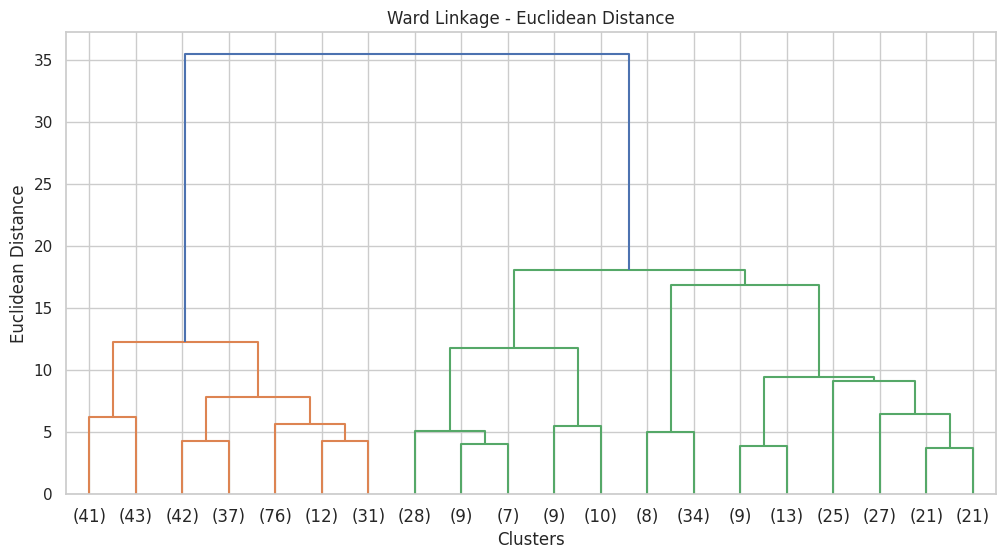

In [69]:
for method in methods:
 Z = linkage(
              X,
                 method=method,
                              metric="euclidean"
                                  )
plt.figure(figsize=(12,6))

dendrogram(
    Z,
    truncate_mode="lastp",
    p=20
    )

plt.title(
           method.capitalize() +
           " Linkage - Euclidean Distance"
           )

plt.xlabel("Clusters")
plt.ylabel("Euclidean Distance")

plt.show()


In [73]:
# AGGLOMERATIVE CLUSTERING
for method in methods:

      model = AgglomerativeClustering(
              n_clusters=3,
                      metric="euclidean",
                              linkage=method
                                  )
labels = model.fit_predict(X)
df[method.capitalize() + "_Cluster"] = labels

print("\n" + method.upper() + " LINKAGE")

print(
         df[
                    method.capitalize() + "_Cluster"
                                   ].value_counts()
                                                   )


WARD LINKAGE
Ward_Cluster
1    282
0    158
2     63
Name: count, dtype: int64


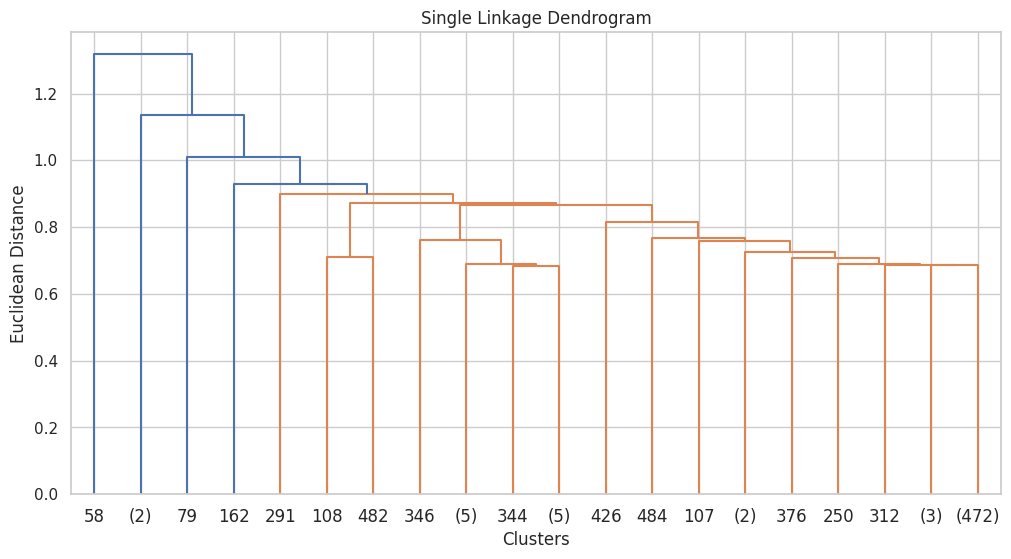

In [76]:
Z_single = linkage(
      X,
          method="single",
              metric="euclidean"
              )
plt.figure(figsize=(12,6))

dendrogram(
           Z_single,
               truncate_mode="lastp",
                      p=20
                          )

plt.title("Single Linkage Dendrogram")
plt.xlabel("Clusters")
plt.ylabel("Euclidean Distance")

plt.show()


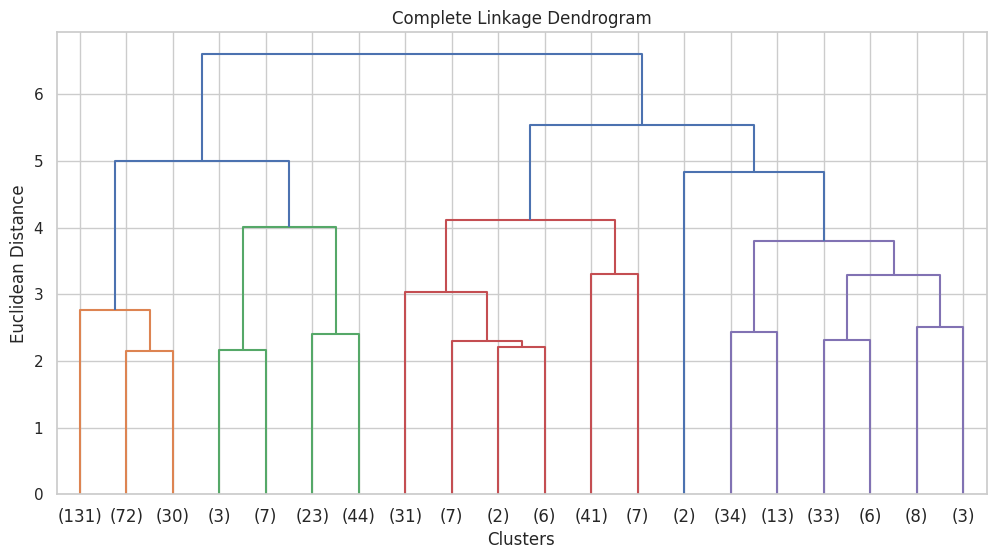

In [77]:
Z_complete = linkage(
      X,
          method="complete",
              metric="euclidean"
              )
plt.figure(figsize=(12,6))

dendrogram(
            Z_complete,
            truncate_mode="lastp",
                p=20
                    )

plt.title("Complete Linkage Dendrogram")
plt.xlabel("Clusters")
plt.ylabel("Euclidean Distance")

plt.show()


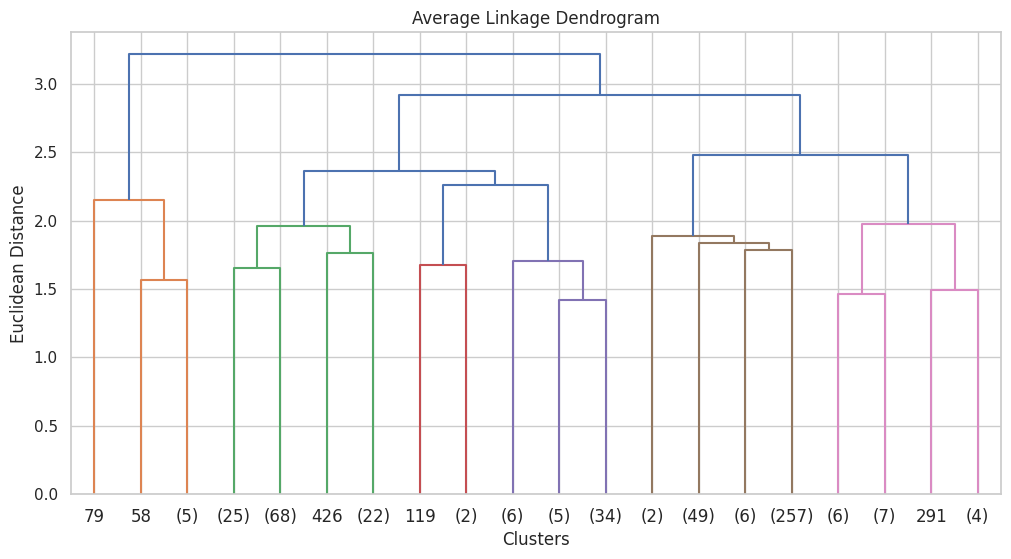

In [78]:
Z_average = linkage(
      X,
          method="average",
              metric="euclidean"
              )

plt.figure(figsize=(12,6))

dendrogram(
           Z_average,
                truncate_mode="lastp",
                    p=20
                          )

plt.title("Average Linkage Dendrogram")
plt.xlabel("Clusters")
plt.ylabel("Euclidean Distance")

plt.show()


Text(0.5, 1.0, 'Ward Linkage - 2D Clustering')

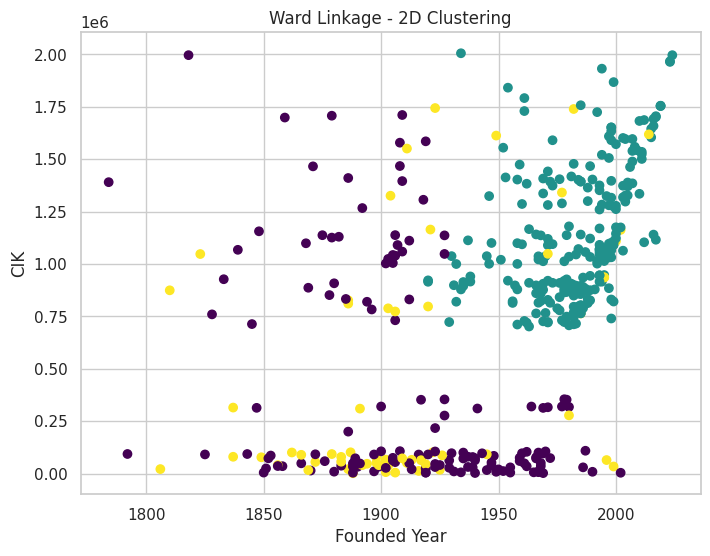

In [83]:
for method in methods:

      column = method.capitalize() + "_Cluster"

plt.figure(figsize=(8,6))

plt.scatter(
df["Founded"],
          df["CIK"],
          c=df[column],
          cmap="viridis"
                  )

plt.xlabel("Founded Year")
plt.ylabel("CIK")
plt.title(
                method.capitalize() +
                                     " Linkage - 2D Clustering"
                                                                    )